In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss
import pickle

In [2]:
df = pd.read_csv('../data/clean/datamahasiswa_clean.csv')

display(df.head())

,JENIS_KELAMIN,STATUS_MAHASISWA,UMUR,STATUS_NIKAH,IPS_1,IPS_2,IPS_3,IPS_4,STATUS_KELULUSAN
0,0,1,28,0,2.76,2.80,3.20,3.17,0
1,0,0,32,0,3.00,3.30,3.14,3.14,0
2,1,1,29,0,3.50,3.30,3.70,3.29,0
3,0,0,27,0,3.17,3.41,3.61,3.36,0
4,0,1,29,0,2.90,2.89,3.30,2.85,0


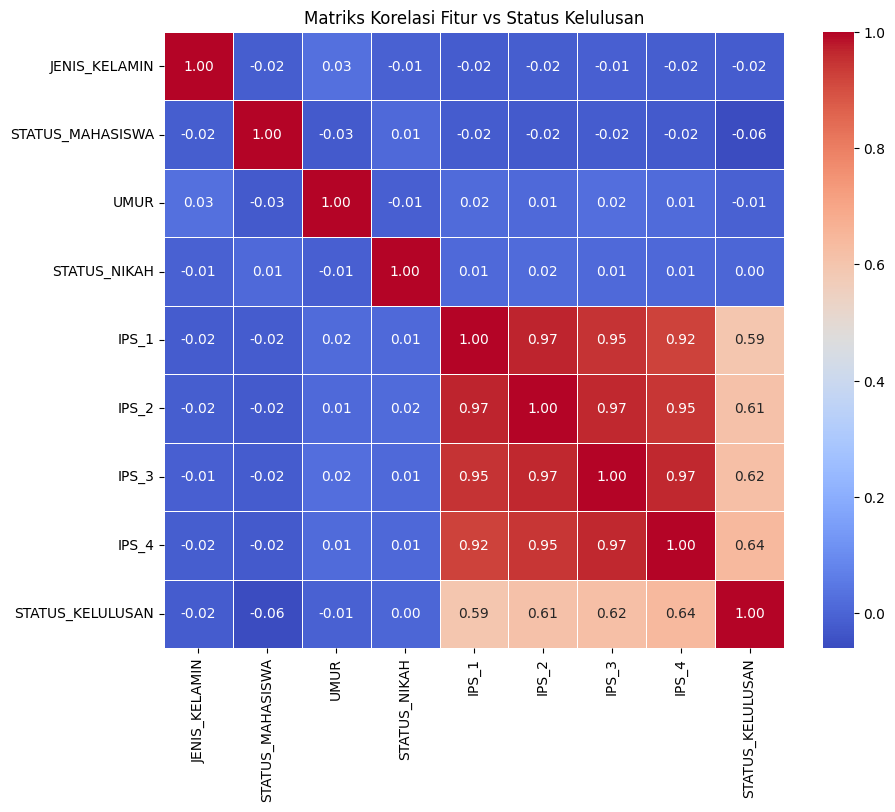

In [3]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriks Korelasi Fitur vs Status Kelulusan')
plt.show()

In [4]:
# Train-Test Split
X = df.drop('STATUS_KELULUSAN', axis=1)
y = df['STATUS_KELULUSAN']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# 4. Train Models with Hyperparameter Tuning

models = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=4,           
        min_samples_leaf=15,   
        random_state=42
    ),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=50, 
        max_depth=4,           
        min_samples_leaf=10,   
        max_features='sqrt',
        random_state=42
    )
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    trained_models[name] = model

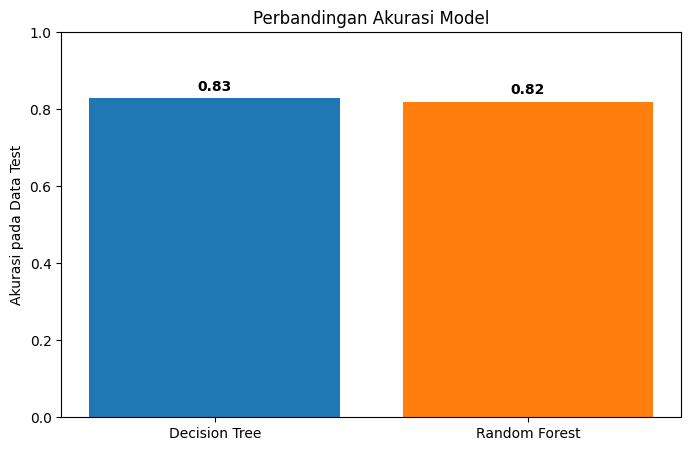

In [6]:
# Bar Chart Perbandingan Akurasi
plt.figure(figsize=(8, 5))
colors = ['#1f77b4', '#ff7f0e']
plt.bar(results.keys(), results.values(), color=colors)
plt.ylim(0, 1)
plt.title('Perbandingan Akurasi Model')
plt.ylabel('Akurasi pada Data Test')

for i, v in enumerate(results.values()):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()

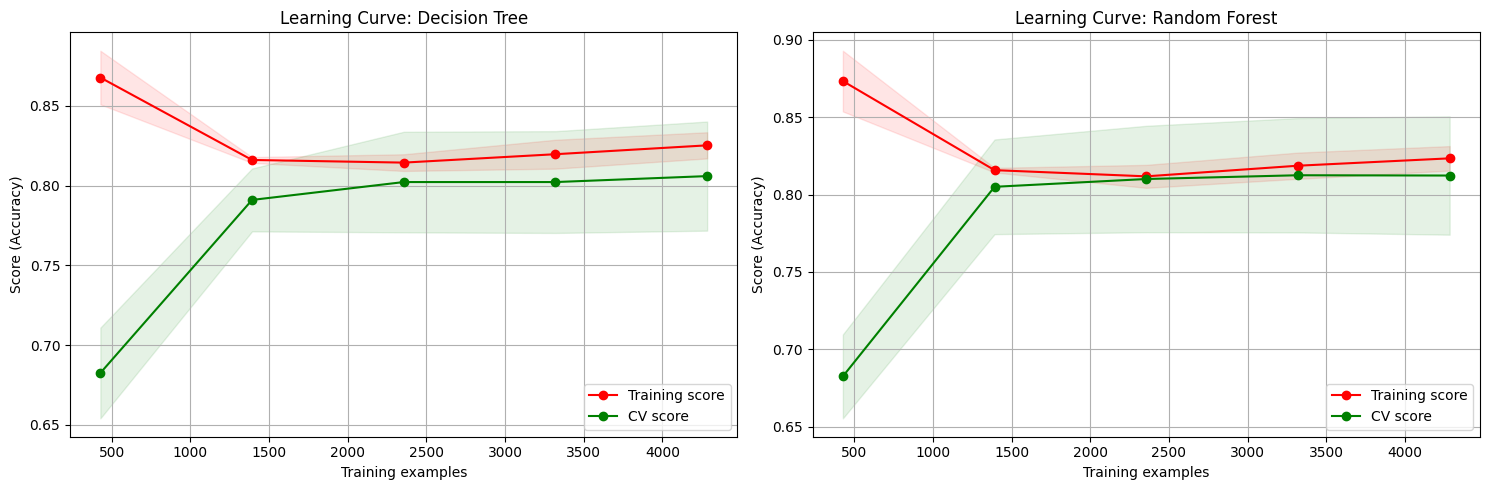

In [7]:
# Plotting Learning Curve
def plot_learning_curve(estimator, title, X, y, ax, cv=5, train_sizes=np.linspace(.1, 1.0, 5)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=train_sizes, scoring='accuracy')
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    ax.grid()
    ax.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    ax.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    ax.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    ax.plot(train_sizes, test_scores_mean, 'o-', color="g", label="CV score")
    ax.set_title(title)
    ax.set_xlabel("Training examples")
    ax.set_ylabel("Score (Accuracy)")
    ax.legend(loc="lower right")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, (name, model) in enumerate(trained_models.items()):
    plot_learning_curve(model, f"Learning Curve: {name}", X, y, ax=axes[i])

plt.tight_layout()
plt.show()

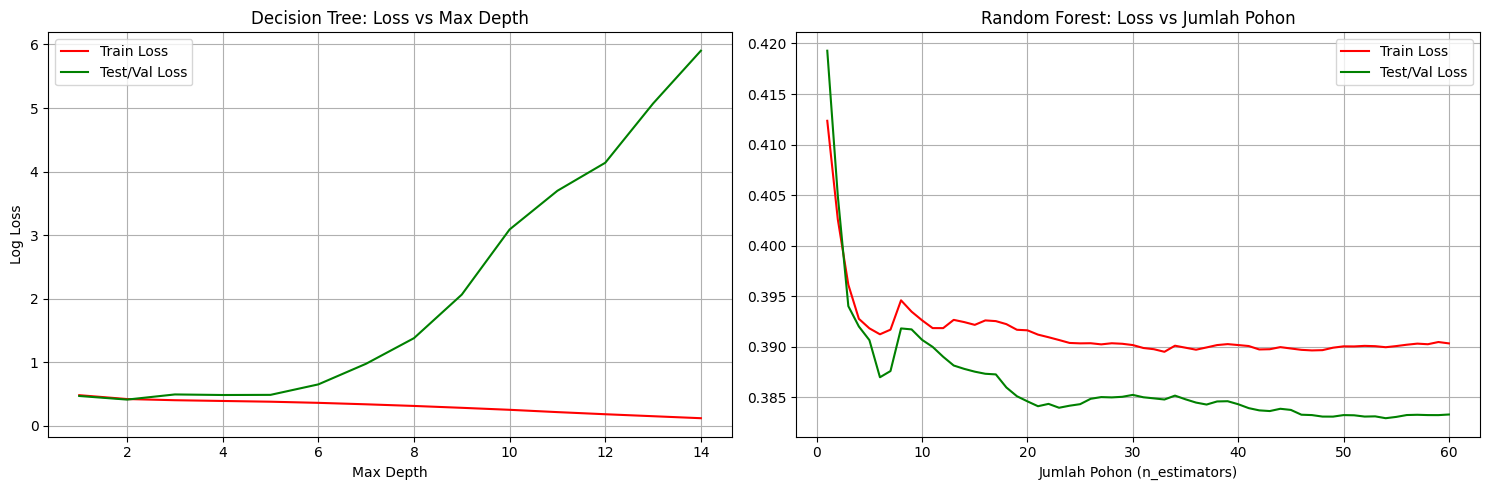

In [8]:
# Loss Curve
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Decision Tree (Loss vs Max Depth) ---
dt_train_loss = []
dt_test_loss = []
depths = range(1, 15)
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    dt_train_loss.append(log_loss(y_train, dt.predict_proba(X_train)))
    dt_test_loss.append(log_loss(y_test, dt.predict_proba(X_test)))

axes[0].plot(depths, dt_train_loss, label='Train Loss', color='red')
axes[0].plot(depths, dt_test_loss, label='Test/Val Loss', color='green')
axes[0].set_title('Decision Tree: Loss vs Max Depth')
axes[0].set_xlabel('Max Depth')
axes[0].set_ylabel('Log Loss')
axes[0].legend()
axes[0].grid(True)

# --- Random Forest (Loss vs Jumlah Pohon) ---
rf = RandomForestClassifier(n_estimators=1, max_depth=4, warm_start=True, random_state=42)
rf_train_loss = []
rf_test_loss = []
estimators_range = range(1, 61)
for i in estimators_range:
    rf.n_estimators = i
    rf.fit(X_train, y_train)
    rf_train_loss.append(log_loss(y_train, rf.predict_proba(X_train)))
    rf_test_loss.append(log_loss(y_test, rf.predict_proba(X_test)))

axes[1].plot(estimators_range, rf_train_loss, label='Train Loss', color='red')
axes[1].plot(estimators_range, rf_test_loss, label='Test/Val Loss', color='green')
axes[1].set_title('Random Forest: Loss vs Jumlah Pohon')
axes[1].set_xlabel('Jumlah Pohon (n_estimators)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [9]:
# Evaluasi Model (Confusion Matrix & Classification Report)
for name, model in trained_models.items():
    print(f"\n{'='*40}")
    print(f"--- Evaluasi Model: {name} ---")
    print(f"{'='*40}")
    y_pred = model.predict(X_test)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


--- Evaluasi Model: Decision Tree ---
Confusion Matrix:
 [[410  97]
 [ 87 477]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.81      0.82       507
           1       0.83      0.85      0.84       564

    accuracy                           0.83      1071
   macro avg       0.83      0.83      0.83      1071
weighted avg       0.83      0.83      0.83      1071


--- Evaluasi Model: Random Forest ---
Confusion Matrix:
 [[403 104]
 [ 90 474]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.81       507
           1       0.82      0.84      0.83       564

    accuracy                           0.82      1071
   macro avg       0.82      0.82      0.82      1071
weighted avg       0.82      0.82      0.82      1071



In [10]:
# Prediksi Data Baru
print("--- Simulasi Prediksi Mahasiswa Baru ---")
data_baru = pd.DataFrame({
    'JENIS_KELAMIN': [1, 0],           # 1: Laki-laki, 0: Perempuan
    'STATUS_MAHASISWA': [0, 1],        # 0: Tidak Bekerja, 1: Bekerja
    'UMUR': [22, 28],
    'STATUS_NIKAH': [0, 1],            # 0: Belum Nikah, 1: Nikah
    'IPS_1': [3.50, 2.70],
    'IPS_2': [3.60, 2.80],
    'IPS_3': [3.45, 2.90],
    'IPS_4': [3.55, 3.00]
})

display(data_baru)

hasil_prediksi = {'Data_ID': ['Mahasiswa 1 (Cemerlang)', 'Mahasiswa 2 (Cukup)']}

for name, model in trained_models.items():
    pred = model.predict(data_baru)
    hasil_prediksi[name] = ['Tepat Waktu' if p == 1 else 'Terlambat' for p in pred]

df_hasil = pd.DataFrame(hasil_prediksi)
display(df_hasil)
print("Penjelasan:\nTabel di atas membandingkan secara langsung tebakan dari ketiga model untuk data baru yang belum pernah mereka lihat.")

--- Simulasi Prediksi Mahasiswa Baru ---


,JENIS_KELAMIN,STATUS_MAHASISWA,UMUR,STATUS_NIKAH,IPS_1,IPS_2,IPS_3,IPS_4
0,1,0,22,0,3.5,3.6,3.45,3.55
1,0,1,28,1,2.7,2.8,2.90,3.00


,Data_ID,Decision Tree,Random Forest
0,Mahasiswa 1 (Cemerlang),Tepat Waktu,Tepat Waktu
1,Mahasiswa 2 (Cukup),Terlambat,Terlambat


Penjelasan:
Tabel di atas membandingkan secara langsung tebakan dari ketiga model untuk data baru yang belum pernah mereka lihat.


In [11]:
# Save Model
best_model = 'Random Forest'
best_model = trained_models[best_model]

pickle.dump(best_model, open('../models/model.pkl', 'wb'))